пункт a

In [1]:
import numpy as np

In [2]:
X = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])

Y = np.array([1, 5, 2])

beta = np.linalg.inv(X.T @ X) @ X.T @ Y

a = beta[0]
b = beta[1]

print('a =', a)
print('b =', b)

Y_pred = X @ beta
E = Y - Y_pred

RSS = E.T @ E

print('Y_pred =', Y_pred)
print('E =', E)
print('RSS =', RSS)

a = -0.33333333333333326
b = 3.666666666666666
Y_pred = [-0.33333333  3.66666667  3.33333333]
E = [ 1.33333333  1.33333333 -1.33333333]
RSS = 5.333333333333334


пункт b

In [3]:
import matplotlib.pyplot as plt

In [4]:

N_ridge = 10000

def lam_ridge(i):
    return 10 * (i + 1) / N_ridge


def beta_ridge(X, Y, lam):
    p = X.shape[1]
    return np.linalg.inv(X.T @ X + lam * np.eye(p)) @ X.T @ Y


CVSS_ridge = np.zeros(N_ridge)

for i in range(N_ridge):
    lam = lam_ridge(i)

    for j in range(3):
        X_train = np.delete(X, j, axis=0)
        Y_train = np.delete(Y, j)

        beta_cur = beta_ridge(X_train, Y_train, lam)

        Y_pred_j = X[j] @ beta_cur

        CVSS_ridge[i] += (Y[j] - Y_pred_j) ** 2


i_opt = np.argmin(CVSS_ridge)

lam_opt_ridge = lam_ridge(i_opt)

beta_ridge_opt = beta_ridge(X, Y, lam_opt_ridge)

a_ridge = beta_ridge_opt[0]
b_ridge = beta_ridge_opt[1]

print('lambda_opt =', lam_opt_ridge)
print('a_ridge =', a_ridge)
print('b_ridge =', b_ridge)
print(f'omega = ({a_ridge:.3f}) xi + ({b_ridge:.3f}) eta')

lambda_opt = 1.506
a_ridge = 0.31154700534075513
b_ridge = 1.907716199275312
omega = (0.312) xi + (1.908) eta


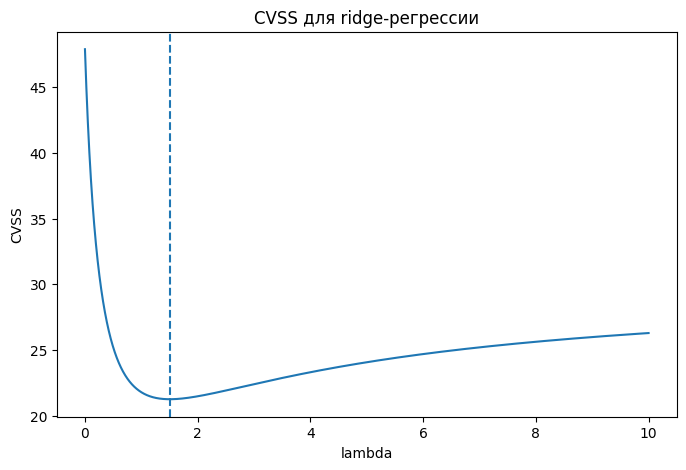

In [5]:
lams_ridge = np.array([lam_ridge(i) for i in range(N_ridge)])

plt.figure(figsize=(8, 5))

plt.plot(lams_ridge, CVSS_ridge)
plt.axvline(lam_opt_ridge, linestyle='--')

plt.xlabel('lambda')
plt.ylabel('CVSS')
plt.title('CVSS для ridge-регрессии')

plt.show()

пункт c

In [12]:
N_lasso = 500

def lam_lasso(i):
    return 10 * (i + 1) / N_lasso


def lasso_value(X, Y, beta, lam):
    E = Y - X @ beta
    RSS = E.T @ E
    penalty = lam * np.sum(np.abs(beta))
    return RSS + penalty


def beta_lasso(X, Y, lam):
    vals = np.linspace(-8, 8, 201)

    best_beta = None
    best_q = None

    for a in vals:
        for b in vals:
            beta_cur = np.array([a, b])
            q = lasso_value(X, Y, beta_cur, lam)

            if best_q is None or q < best_q:
                best_q = q
                best_beta = beta_cur

    return best_beta

In [13]:
CVSS_lasso = np.zeros(N_lasso)

for i in range(N_lasso):
    lam = lam_lasso(i)

    for j in range(3):
        X_train = np.delete(X, j, axis=0)
        Y_train = np.delete(Y, j)

        beta_cur = beta_lasso(X_train, Y_train, lam)

        Y_pred_j = X[j] @ beta_cur

        CVSS_lasso[i] += (Y[j] - Y_pred_j) ** 2

In [14]:
i_opt = np.argmin(CVSS_lasso)

lam_opt_lasso = lam_lasso(i_opt)

beta_lasso_opt = beta_lasso(X, Y, lam_opt_lasso)

a_lasso = beta_lasso_opt[0]
b_lasso = beta_lasso_opt[1]

print('lambda_opt =', lam_opt_lasso)
print('a_lasso =', a_lasso)
print('b_lasso =', b_lasso)
print(f'omega = ({a_lasso:.3f}) xi + ({b_lasso:.3f}) eta')

lambda_opt = 5.92
a_lasso = 0.0
b_lasso = 2.0
omega = (0.000) xi + (2.000) eta


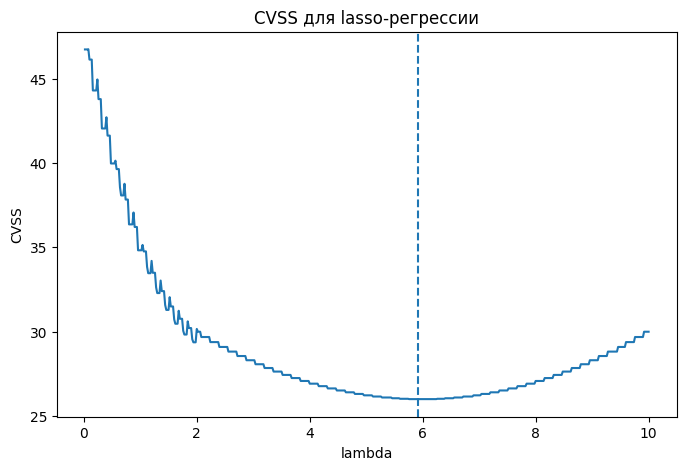

In [15]:
lams_lasso = np.array([lam_lasso(i) for i in range(N_lasso)])

plt.figure(figsize=(8, 5))

plt.plot(lams_lasso, CVSS_lasso)
plt.axvline(lam_opt_lasso, linestyle='--')

plt.xlabel('lambda')
plt.ylabel('CVSS')
plt.title('CVSS для lasso-регрессии')

plt.show()